## EDA

### Load relevant libraries

In [2]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

### Read in the Data

In [3]:
# Set working directory (necessary until 2019 data comes out)
path = 'C:/Users/caanm/OneDrive/Documents/Project Portfolio/OSMH/Data'
os.chdir(path)

In [4]:
df = pd.read_csv('cleaned_data.csv')

### Summarize data

In [5]:
df.head()

,age,gender,country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_vs_physical,obs_consequence,comments,survey_year,age_group,self_employed_enc,treatment_enc,tech_company_enc,obs_consequence_enc,gender_enc_Female,gender_enc_Male,gender_enc_Other,family_history_enc,work_interfere_enc,no_employees_enc_1-5,no_employees_enc_100-500,no_employees_enc_26-100,no_employees_enc_500-1000,no_employees_enc_6-25,no_employees_enc_More than 1000,remote_work_enc_Always,remote_work_enc_Never,remote_work_enc_No,remote_work_enc_Sometimes,remote_work_enc_Yes,benefits_enc,care_options_enc,wellness_program_enc,seek_help_enc,anonymity_enc,leave_enc,mental_health_consequence_enc_Maybe,mental_health_consequence_enc_No,mental_health_consequence_enc_Yes,phys_health_consequence_enc_Maybe,phys_health_consequence_enc_No,phys_health_consequence_enc_Yes,coworkers_enc_No,coworkers_enc_Some of them,coworkers_enc_Yes,supervisor_enc_No,supervisor_enc_Some of them,supervisor_enc_Yes,mental_vs_physical_enc,age_group_enc_18-24,age_group_enc_25-34,age_group_enc_35-44,age_group_enc_45-54,age_group_enc_55-64,age_group_enc_65+,support_score
0,37.0,Female,United States,NaN,No,1,Often,6-25,No,1.0,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,Yes,0.0,NaN,2014,35-44,NaN,1,1.0,0.0,True,False,False,0,3.0,False,False,False,False,True,False,False,False,True,False,False,1,2,0,1,1,1.0,False,True,False,False,True,False,False,True,False,False,False,True,1,False,False,True,False,False,False,1
1,44.0,Male,United States,NaN,No,0,Rarely,More than 1000,No,0.0,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,Don't know,0.0,NaN,2014,35-44,NaN,0,0.0,0.0,False,True,False,0,1.0,False,False,False,False,False,True,False,False,True,False,False,2,0,2,2,2,NaN,True,False,False,False,True,False,True,False,False,True,False,False,2,False,False,True,False,False,False,0
2,32.0,Male,Canada,NaN,No,0,Rarely,6-25,No,1.0,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,No,0.0,NaN,2014,25-34,NaN,0,1.0,0.0,False,True,False,0,1.0,False,False,False,False,True,False,False,False,True,False,False,0,0,0,0,2,3.0,False,True,False,False,True,False,False,False,True,False,False,True,0,False,True,False,False,False,False,0
3,31.0,Male,United Kingdom,NaN,Yes,1,Often,26-100,No,1.0,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,No,1.0,NaN,2014,25-34,NaN,1,1.0,1.0,False,True,False,1,3.0,False,False,True,False,False,False,False,False,True,False,False,0,1,0,0,0,3.0,False,False,True,False,False,True,False,True,False,True,False,False,0,False,True,False,False,False,False,1
4,31.0,Male,United States,NaN,No,0,Never,100-500,Yes,1.0,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Don't know,0.0,NaN,2014,25-34,NaN,0,1.0,0.0,False,True,False,0,0.0,False,True,False,False,False,False,False,False,False,False,True,1,0,2,2,2,NaN,False,True,False,False,True,False,False,True,False,False,False,True,2,False,True,False,False,False,False,1


In [6]:
df.shape

(4677, 71)

In [7]:
survey_count = df.groupby('survey_year').size()
survey_count

survey_year
2014    1251
2016    1428
2017     754
2018     417
2019     351
2020     178
2021     129
2022     163
2023       6
dtype: int64

##### Survey count drops drastically in later years
> ##### Only 10% of responses are from 2020 onwards
> ##### 6 responses in 2023 is incredibly minimal

### Missingness

##### Given the nature of the dataset, it is especially important to look for missingness
> ##### Is it random or structured?
> ##### Are certain columns always answered together
> ##### Are sensitive questions systematically skipped?
##### If sensitive questions are often skipped, it may reflect fear, stigma, or privacy concerns
##### Missingness may predict outcomes and be of import for behavioral segmentation and propensity modeling

<Figure size 1200x600 with 0 Axes>

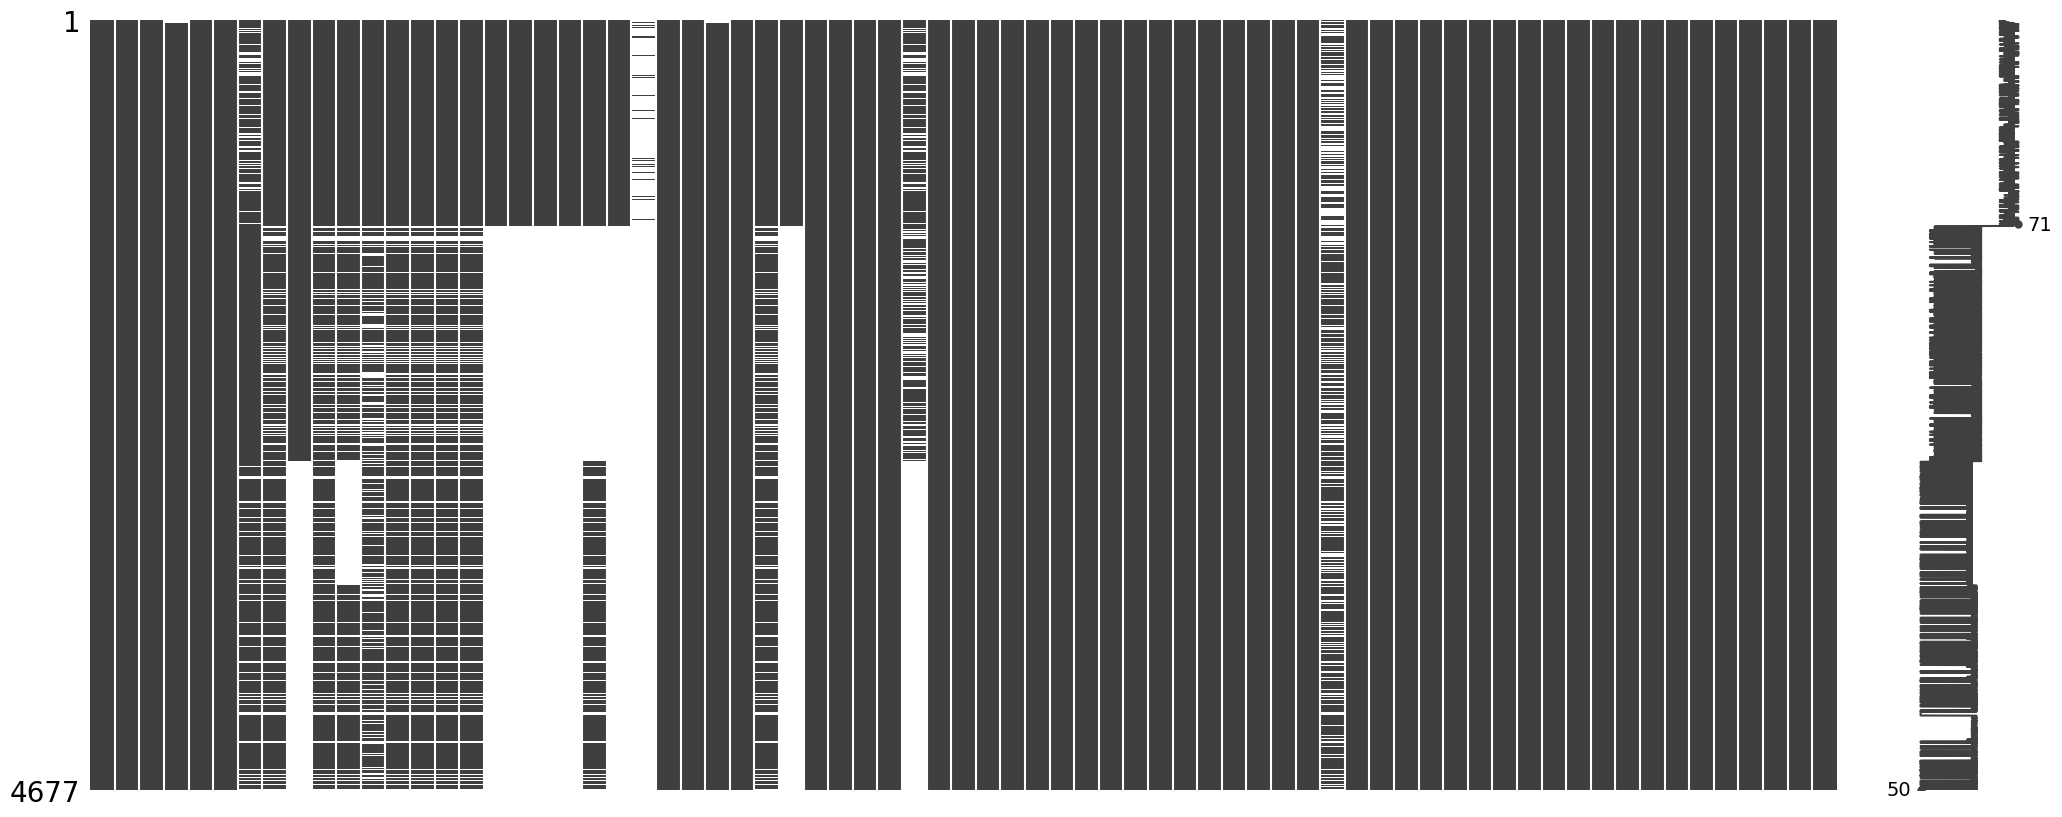

In [8]:
### Missingness matrix
plt.figure(figsize=(12,6))
msno.matrix(df)
plt.show()

##### Large swaths of missingness that bear investigation

In [9]:
missing_summary = df.isna().sum().sort_values(ascending=False).reset_index()
missing_summary.columns = ['variable', 'missing_count']
missing_summary['missing_pct'] = missing_summary['missing_count'] / len(df) * 100
missing_summary

,variable,missing_count,missing_pct
0,comments,4516,96.557622
1,phys_health_consequence,3426,73.252085
2,mental_health_consequence,3426,73.252085
3,obs_consequence_enc,3426,73.252085
4,obs_consequence,3426,73.252085
5,supervisor,3426,73.252085
6,coworkers,3426,73.252085
7,work_interfere_enc,2726,58.285226
8,remote_work,1998,42.719692
9,mental_vs_physical,1723,36.839855


##### Comments are largely missing, which is expected as its a free form field
##### The 'consequence' variables, supervisor, and coworkers tend to have large missing numbers
##### work_interfere_enc missings are somewhat due to encoding definition - several responses did not fall cleanly into Never/Rarely/Sometimes/Often
##### Family_history, treatment, self_employed have very low missingness

In [10]:
### Missingness by Year
missing_by_year = df.groupby('survey_year').apply(lambda x: x.isna().sum(), include_groups=False)
missing_by_year

,age,gender,country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_vs_physical,obs_consequence,comments,age_group,self_employed_enc,treatment_enc,tech_company_enc,obs_consequence_enc,gender_enc_Female,gender_enc_Male,gender_enc_Other,family_history_enc,work_interfere_enc,no_employees_enc_1-5,no_employees_enc_100-500,no_employees_enc_26-100,no_employees_enc_500-1000,no_employees_enc_6-25,no_employees_enc_More than 1000,remote_work_enc_Always,remote_work_enc_Never,remote_work_enc_No,remote_work_enc_Sometimes,remote_work_enc_Yes,benefits_enc,care_options_enc,wellness_program_enc,seek_help_enc,anonymity_enc,leave_enc,mental_health_consequence_enc_Maybe,mental_health_consequence_enc_No,mental_health_consequence_enc_Yes,phys_health_consequence_enc_Maybe,phys_health_consequence_enc_No,phys_health_consequence_enc_Yes,coworkers_enc_No,coworkers_enc_Some of them,coworkers_enc_Yes,supervisor_enc_No,supervisor_enc_Some of them,supervisor_enc_Yes,mental_vs_physical_enc,age_group_enc_18-24,age_group_enc_25-34,age_group_enc_35-44,age_group_enc_45-54,age_group_enc_55-64,age_group_enc_65+,support_score
survey_year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014,0,0,0,18,0,0,262,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1090,0,18,0,0,0,0,0,0,0,262,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,561,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,286,0,286,286,418,286,286,286,286,1428,1428,1428,1428,1428,1428,1428,0,0,0,286,1428,0,0,0,0,466,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,435,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2017,0,0,0,0,0,0,111,111,754,111,754,178,111,111,111,111,754,754,754,754,111,754,754,0,0,0,111,754,0,0,0,0,754,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,216,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2018,0,0,0,0,0,0,56,56,417,56,56,93,56,56,56,56,417,417,417,417,56,417,417,0,0,0,56,417,0,0,0,0,417,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,128,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2019,0,0,0,0,0,0,48,48,351,48,48,74,48,48,48,48,351,351,351,351,48,351,351,0,0,0,48,351,0,0,0,0,351,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2020,0,0,0,0,0,0,23,23,178,23,23,45,23,23,23,23,178,178,178,178,23,178,178,0,0,0,23,178,0,0,0,0,178,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2021,0,0,0,0,0,0,16,16,129,16,16,27,16,16,16,16,129,129,129,129,16,129,129,0,0,0,16,129,0,0,0,0,129,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,31,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2022,0,0,0,0,0,0,39,39,163,39,39,50,39,39,39,39,163,163,163,163,39,163,163,0,0,0,39,163,0,0,0,0,163,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,53,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023,0,0,0,0,0,0,2,2,6,2,2,2,2,2,2,2,6,6,6,6,2,6,6,0,0,0,2,6,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


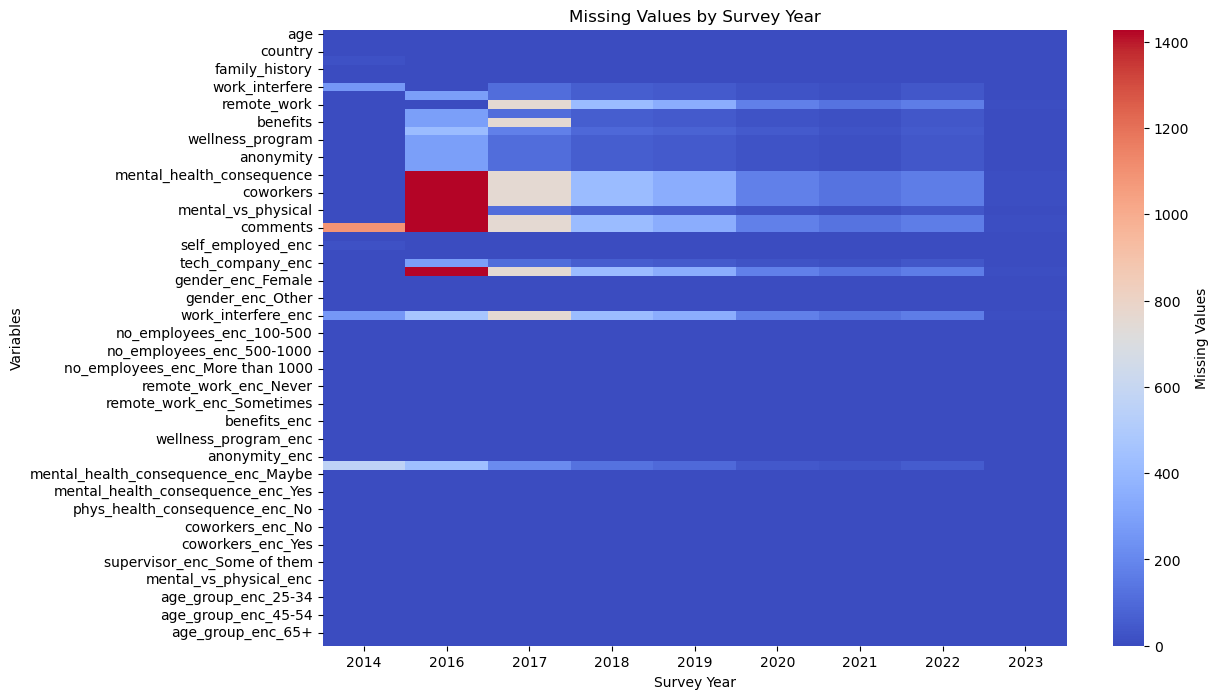

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(missing_by_year.T, cmap='coolwarm', cbar_kws={'label':'Missing Values'})
plt.title('Missing Values by Survey Year')
plt.xlabel('Survey Year')
plt.ylabel('Variables')
plt.show()

##### Work_interfere is mostly missing in 2014, almost complete in later years
> ##### Likely reflects changes in survey design
##### Many variables have missingness concentrated in early survey years (2014, 2016)
> ##### mental_health_consequence, phys_health_consequence, supervisor, coworkers all have 1428 missing in 2016
> ##### These questions either weren't asked or weren't answered consistently. Perhaps optional at the time?
##### Variables with high missingness in early years seem to nearly dissipate by 2020, which would be important for modeling
> ##### However, earlier results showed that later years had significantly smaller sample size

#### 2020+ missingness

In [12]:
df_2020 = df[df['survey_year'] >= 2020].copy()

In [13]:
display(df_2020.head(), df_2020.shape)

,age,gender,country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_vs_physical,obs_consequence,comments,survey_year,age_group,self_employed_enc,treatment_enc,tech_company_enc,obs_consequence_enc,gender_enc_Female,gender_enc_Male,gender_enc_Other,family_history_enc,work_interfere_enc,no_employees_enc_1-5,no_employees_enc_100-500,no_employees_enc_26-100,no_employees_enc_500-1000,no_employees_enc_6-25,no_employees_enc_More than 1000,remote_work_enc_Always,remote_work_enc_Never,remote_work_enc_No,remote_work_enc_Sometimes,remote_work_enc_Yes,benefits_enc,care_options_enc,wellness_program_enc,seek_help_enc,anonymity_enc,leave_enc,mental_health_consequence_enc_Maybe,mental_health_consequence_enc_No,mental_health_consequence_enc_Yes,phys_health_consequence_enc_Maybe,phys_health_consequence_enc_No,phys_health_consequence_enc_Yes,coworkers_enc_No,coworkers_enc_Some of them,coworkers_enc_Yes,supervisor_enc_No,supervisor_enc_Some of them,supervisor_enc_Yes,mental_vs_physical_enc,age_group_enc_18-24,age_group_enc_25-34,age_group_enc_35-44,age_group_enc_45-54,age_group_enc_55-64,age_group_enc_65+,support_score
4201,45.0,Male,United States of America,1.0,Yes,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,45-54,1.0,0,NaN,NaN,False,True,False,1,NaN,False,False,False,False,False,False,False,False,False,False,False,2,2,2,2,2,NaN,False,False,False,False,False,False,False,False,False,False,False,False,2,False,False,False,True,False,False,0
4202,24.0,Female,Russia,1.0,Yes,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,18-24,1.0,1,NaN,NaN,True,False,False,1,NaN,False,False,False,False,False,False,False,False,False,False,False,2,2,2,2,2,NaN,False,False,False,False,False,False,False,False,False,False,False,False,2,True,False,False,False,False,False,0
4203,46.0,Male,India,1.0,Yes,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,45-54,1.0,0,NaN,NaN,False,True,False,1,NaN,False,False,False,False,False,False,False,False,False,False,False,2,2,2,2,2,NaN,False,False,False,False,False,False,False,False,False,False,False,False,2,False,False,False,True,False,False,0
4204,25.0,Female,Canada,1.0,Yes,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,25-34,1.0,0,NaN,NaN,True,False,False,1,NaN,False,False,False,False,False,False,False,False,False,False,False,2,2,2,2,2,NaN,False,False,False,False,False,False,False,False,False,False,False,False,2,False,True,False,False,False,False,0
4205,25.0,Female,Canada,1.0,I don't know,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,25-34,1.0,0,NaN,NaN,True,False,False,2,NaN,False,False,False,False,False,False,False,False,False,False,False,2,2,2,2,2,NaN,False,False,False,False,False,False,False,False,False,False,False,False,2,False,True,False,False,False,False,0


(476, 71)

In [14]:
missing_summary = df_2020.isna().sum().sort_values(ascending=False).reset_index()
missing_summary.columns = ['variable', 'missing_count']
missing_summary['missing_pct'] = missing_summary['missing_count'] / len(df_2020) * 100
missing_summary

,variable,missing_count,missing_pct
0,comments,476,100.000000
1,remote_work,476,100.000000
2,obs_consequence_enc,476,100.000000
3,obs_consequence,476,100.000000
4,supervisor,476,100.000000
5,coworkers,476,100.000000
6,phys_health_consequence,476,100.000000
7,mental_health_consequence,476,100.000000
8,work_interfere_enc,476,100.000000
9,leave_enc,130,27.310924


##### Earlier missingness analysis looked specifically at raw counts of NaN per variable, giving the impression that 2020+ had a more complete set of responses
##### Unfortunately, when looking at proportion of responses, several variables are completely missing from this subset

### Distributions

#### Numeric & Ordinal Variables

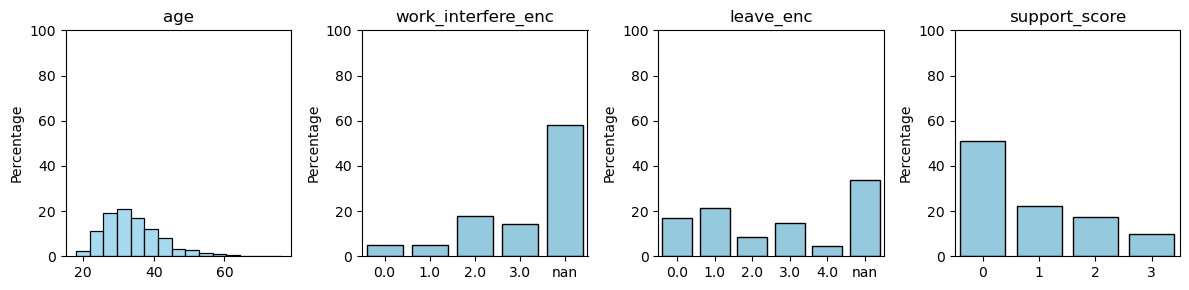

In [48]:
# Numeric / ordinal variables
numeric_cols = ['age', 'work_interfere_enc', 'leave_enc', 'support_score']

# Determine grid size
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols*3, n_rows*3))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # For ordinal variables (integers), plot percentage bars
    if df[col].dtype in ['int64', 'float64'] and df[col].nunique() < 10:
        counts = df[col].value_counts(dropna=False).sort_index()
        percentages = counts / counts.sum() * 100
        sns.barplot(x=percentages.index.astype(str), y=percentages.values,
                    color='skyblue', edgecolor='black')
        plt.ylabel('Percentage')
    else:
        # For continuous variables, use histogram with density
        sns.histplot(df[col].dropna(), bins=15, stat='percent', color='skyblue', edgecolor='black')
        plt.ylabel('Percentage')
    
    plt.title(col)
    plt.xlabel('')
    plt.ylim(0, 100)

plt.tight_layout()
plt.show()

#### Binary / Ternary Counts

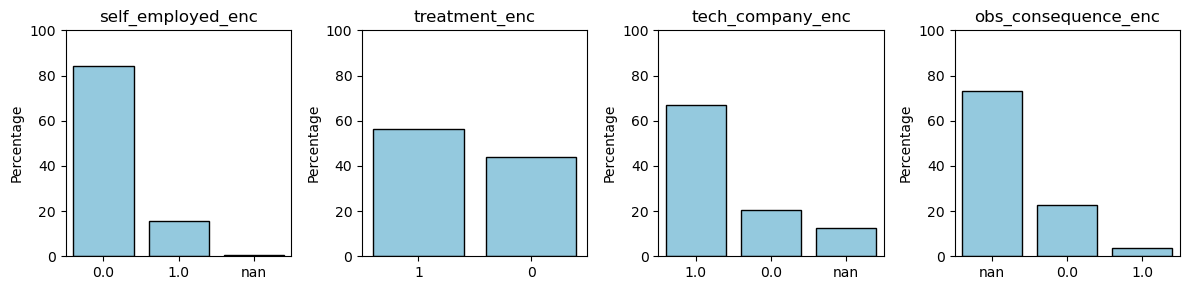

In [49]:
binary_cols = ['self_employed_enc', 'treatment_enc', 'tech_company_enc', 'obs_consequence_enc']

# Determine grid size
n_cols = 4
n_rows = (len(binary_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols*3, n_rows*3))

for i, col in enumerate(binary_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    counts = df[col].value_counts(dropna=False)
    percentages = counts / counts.sum() * 100
    
    sns.barplot(x=percentages.index.astype(str), y=percentages.values, color='skyblue', edgecolor='black')
    
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Percentage')
    plt.ylim(0, 100)
plt.tight_layout()
plt.show()

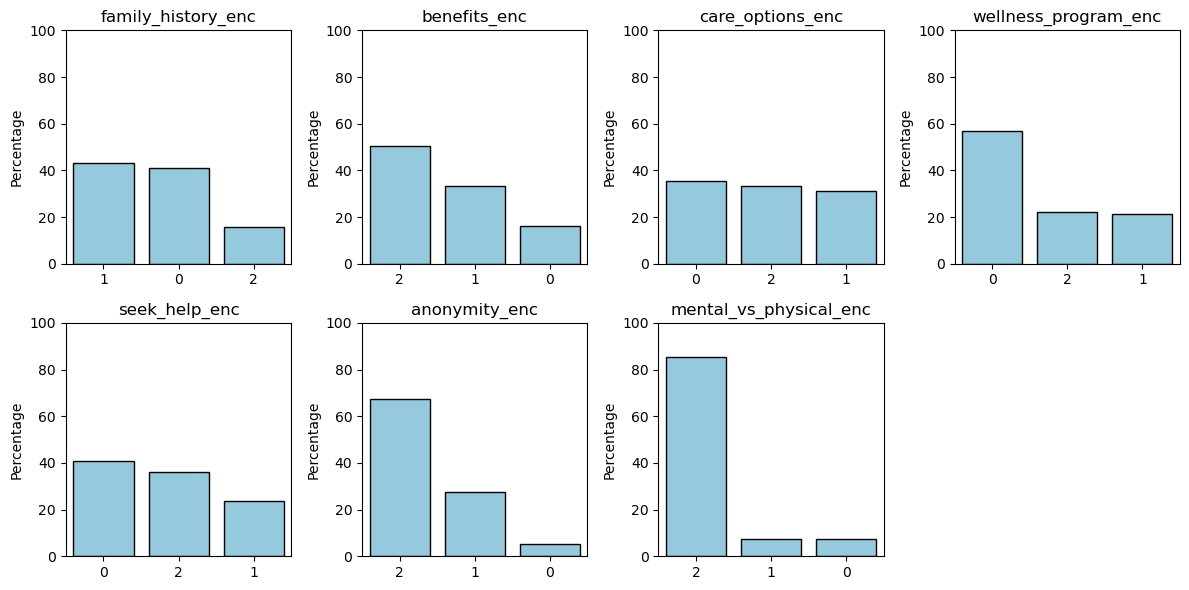

In [50]:
ternary_cols = ['family_history_enc', 'benefits_enc', 'care_options_enc', 'wellness_program_enc', 
               'seek_help_enc', 'anonymity_enc', 'mental_vs_physical_enc']

# Determine grid size
n_cols = 4
n_rows = (len(ternary_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols*3, n_rows*3))

for i, col in enumerate(ternary_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    counts = df[col].value_counts(dropna=False)
    percentages = counts / counts.sum() * 100
    
    sns.barplot(x=percentages.index.astype(str), y=percentages.values, color='skyblue', edgecolor='black')
    
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Percentage')
    plt.ylim(0, 100)
plt.tight_layout()
plt.show()

#### Correlation

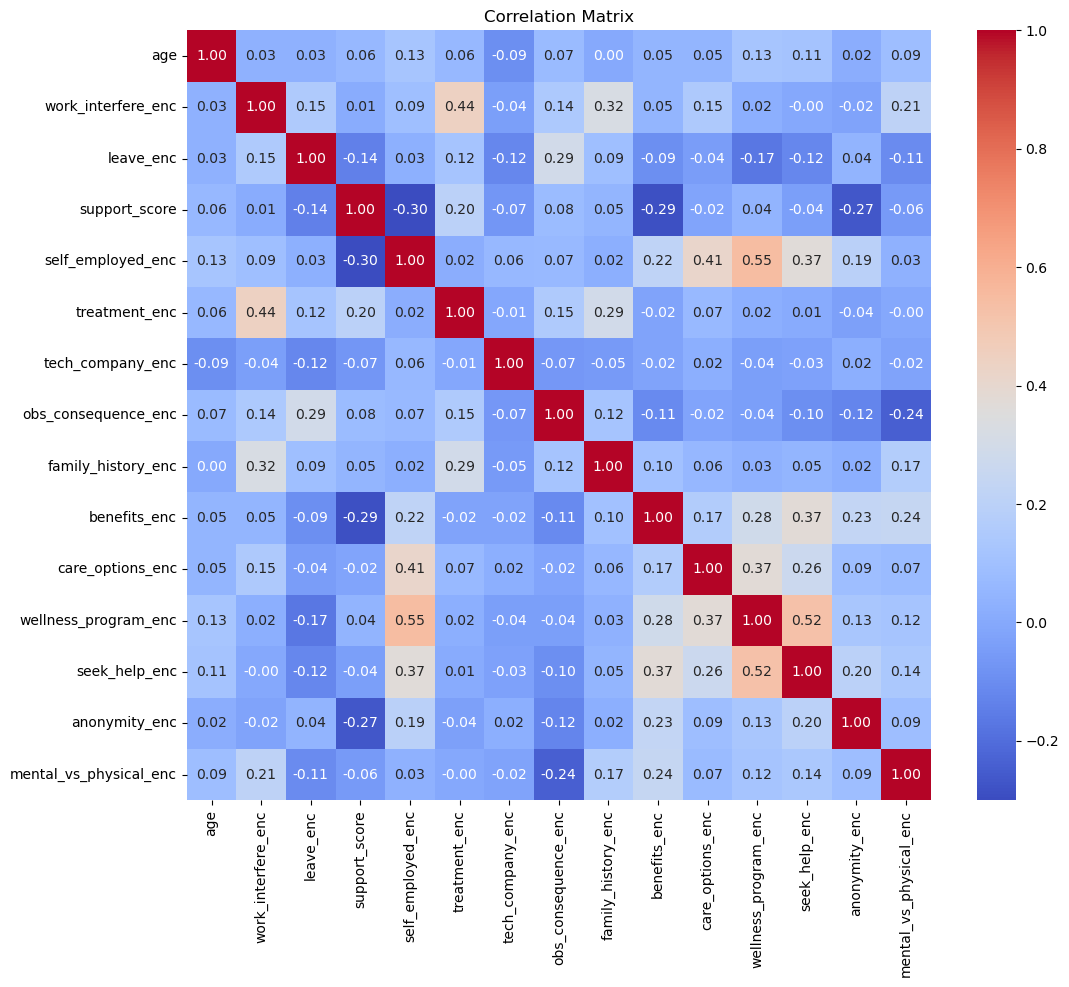

In [51]:
corr_cols = numeric_cols + binary_cols + ternary_cols
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

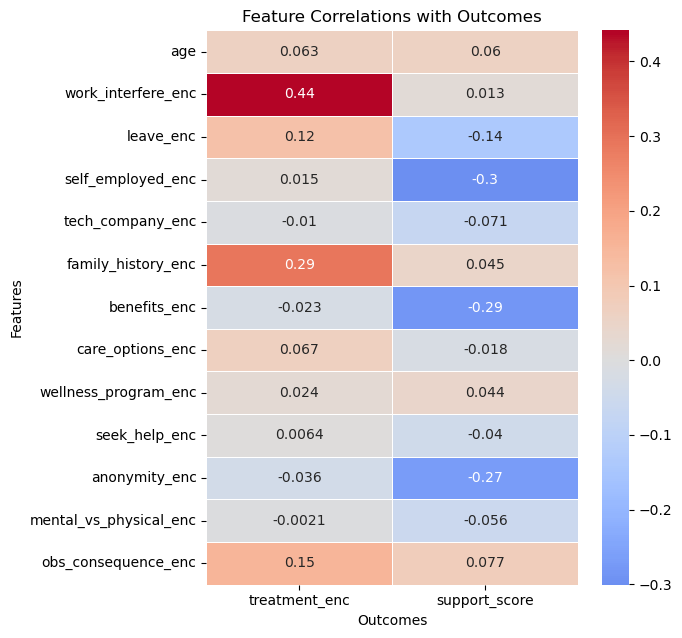

In [52]:
# Features to include
numeric_cols = ['age', 'work_interfere_enc', 'leave_enc']
binary_cols = ['self_employed_enc', 'tech_company_enc', 'family_history_enc',
               'benefits_enc', 'care_options_enc', 'wellness_program_enc', 
               'seek_help_enc', 'anonymity_enc', 'mental_vs_physical_enc', 'obs_consequence_enc']

features = numeric_cols + binary_cols
outcomes = ['treatment_enc', 'support_score']

# Compute correlations
corr_matrix = df[features + outcomes].corr()[outcomes].drop(index=outcomes)

# Plot heatmap
plt.figure(figsize=(6, len(features)*0.4 + 2))  # dynamic height based on #features
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlations with Outcomes')
plt.ylabel('Features')
plt.xlabel('Outcomes')
plt.show()

##### Correlations with Treatment:
> ##### work_interfere: those who report mental health inteferes with work are more likely to seek treatment
> ##### family_history: those with a family histor of mental illness are more likely to seek treatment
> ##### obs_consequence: seeing negative consequences for coworkers has a smaller positive corrleation
##### Strongest correlations are positive, suggesting that factors are more likely to influence people to seek care
#####
##### Correlations with Supprt_Score (benefits + care options + wellness program)
> ##### self_employed: self-employed people tend to have lower workplace support
> ##### benefits: surprisingly negative, may be due to encoding where don't know/not eligible = 2
> ##### anonymity: low anonymity is associated with lower perceived support
##### Strongest correlations are negative, suggesting that factors are likely to depress perceived support

##### High correlation features for treatment are good candidates for propensity modeling
##### High correlation features for support score are good candidates for segmentation and clustering
##### 'Don't Know' responses may be worth reviewing the encoding, so they don't unduly influence results 

### Outcome/Split Comparisons

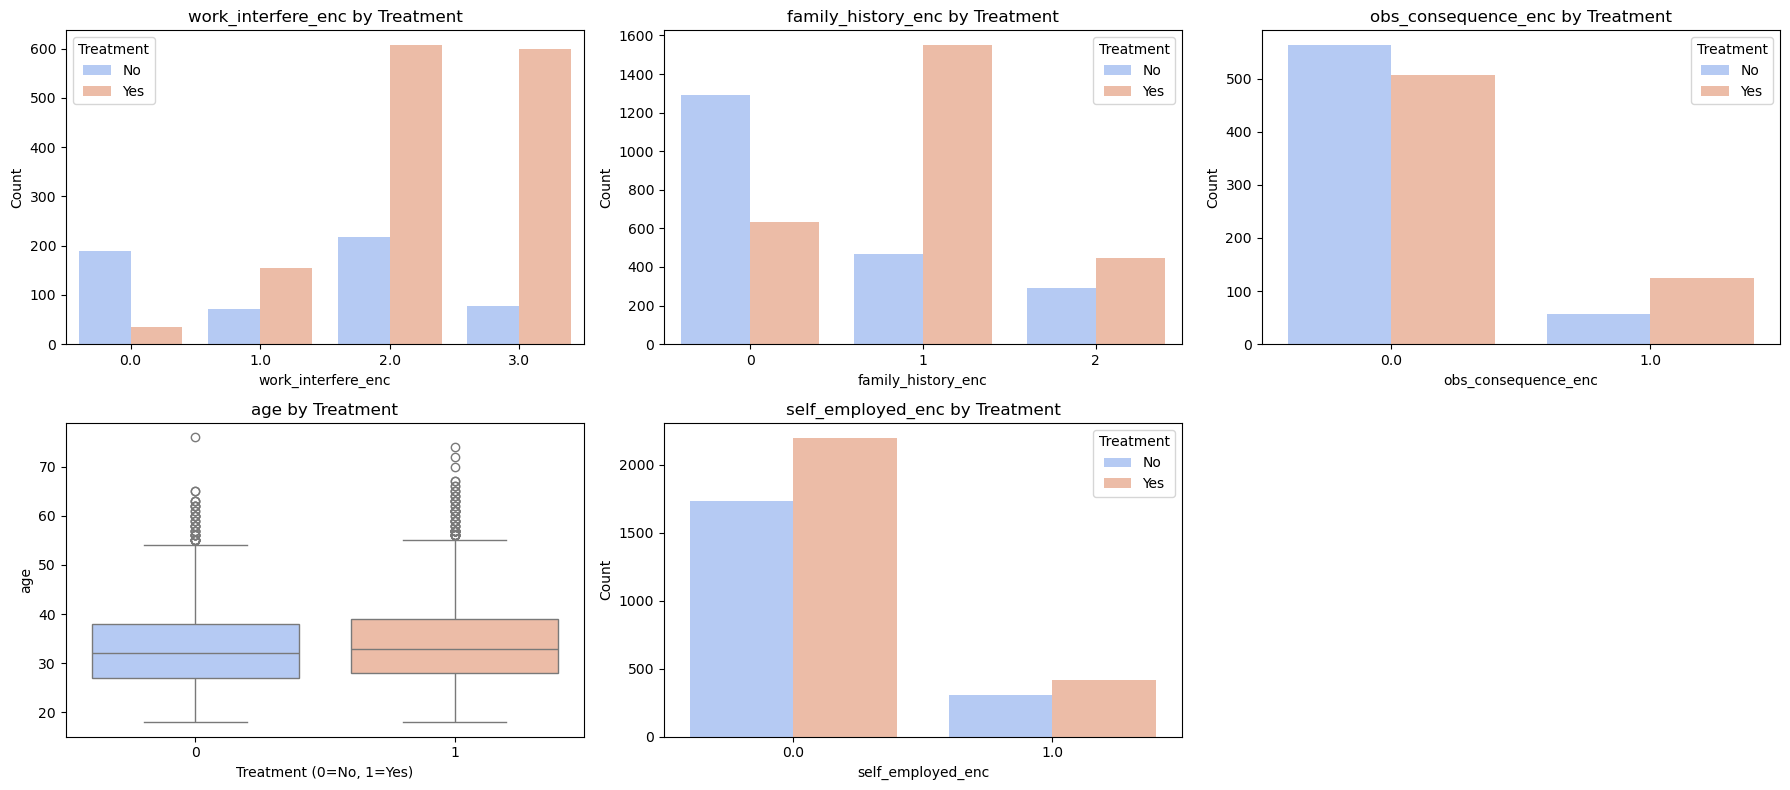

In [53]:
# Features to visualize
features_to_plot = ['work_interfere_enc', 'family_history_enc', 'obs_consequence_enc', 'age', 'self_employed_enc']

n_cols = 3
n_rows = (len(features_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols*6, n_rows*4))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    
    if df[col].nunique() <= 5:  # categorical / ordinal
        sns.countplot(x=col, hue='treatment_enc', data=df, palette='coolwarm')
        plt.ylabel('Count')
        plt.legend(title='Treatment', labels=['No', 'Yes'])
    else:  # continuous
        sns.boxplot(x='treatment_enc', y=col, data=df, palette='coolwarm', hue='treatment_enc', legend=False)
        plt.ylabel(col)
        plt.xlabel('Treatment (0=No, 1=Yes)')
    
    plt.title(f'{col} by Treatment')

plt.tight_layout()
plt.show()

##### Results mirror correlation:
> ##### Those who say mental health inteferes with work are significantly more likely to seek treatment
> ##### Same with having a family history of mental illness
> ##### The effect for obs_consequence is smaller, but still noticeable
##### Age seems to have little bearing on seeking treatment
##### Neither does employment type